In [1]:
#Import useful libraries
#Import pandas for loading and exploring tabular data
import pandas as pd

#Import numpy for basic numerical operations
import numpy as np

#Import matplot for plotting
import matplotlib.pyplot as plt

#Import seaborn for statistical visualisations
import seaborn as sns
from numpy.random.c_distributions import random_standard_normal

#Enable inline plotting so figures appear in the notebook
%matplotlib inline

In [2]:
#Load datset 2 from CSV into a pandas DataFrame
dataset2 = pd.read_csv('credit_dataset2.csv')

#Show first 5 rows
print("First 5 rows of the dataset:")
print(dataset2.head())

First 5 rows of the dataset:
      CUST_ID  INCOME  SAVINGS     DEBT  R_SAVINGS_INCOME  R_DEBT_INCOME  \
0  C02COQEVYU   33269        0   532304            0.0000        16.0000   
1  C02OZKC0ZF   77158    91187   315648            1.1818         4.0909   
2  C03FHP2D0A   30917    21642   534864            0.7000        17.3000   
3  C03PVPPHOY   80657    64526   629125            0.8000         7.8000   
4  C04J69MUX0  149971  1172498  2399531            7.8182        16.0000   

   R_DEBT_SAVINGS  T_CLOTHING_12  R_CLOTHING  R_CLOTHING_INCOME  ...  \
0          1.2000           1889      0.5003             0.0568  ...   
1          3.4615           5818      0.0191             0.0754  ...   
2         24.7142           1157      0.7433             0.0374  ...   
3          9.7499           6857      0.5376             0.0850  ...   
4          2.0465           1978      0.1628             0.0132  ...   

   R_UTILITIES_SAVINGS  R_UTILITIES_DEBT  T_EXPENDITURE_12  R_EXPENDITURE  \
0   

In [3]:
#Remove customer id
dataset2 = dataset2.drop(columns='CUST_ID')

#Check the dataset after removal
print(dataset2.shape)
print('CUST_ID' in dataset2.columns)

(1000, 69)
False


In [4]:
#Check target variable is there
print('DEFAULT' in dataset2.columns)

True


In [5]:
#Separate features (independent variables) and target (dependent variable)
#Drop the 'DEFAULT' column (target)

#Feature matrix without target
X = dataset2.drop (["DEFAULT"], axis = 1)

#Target vector is DEFAULT
y = dataset2 ["DEFAULT"]

#Import train_test_split data into training and test sets
from sklearn.model_selection import train_test_split

#Split the dataset into training and test sets
#Use 20% of samples for testing by doing test_size=0.2
#random_state is set for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42

)

#Print the shapes of the resulting arrays to confirm the split
print("\nShape of X_train.shape:", X_train.shape)
print("\nShape of X_test.shape:", X_test.shape)
print("\nShape of y_train.shape:", y_train.shape)
print("\nShape of y_test.shape:", y_test.shape)



Shape of X_train.shape: (800, 68)

Shape of X_test.shape: (200, 68)

Shape of y_train.shape: (800,)

Shape of y_test.shape: (200,)


Next Logistic Regression

In [6]:
#Import Logistic Regression libraries
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

#Use standard scaler to transform data as target variable is imbalanced
logistic_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
    max_iter = 200,
    class_weight = 'balanced'
    ))
])

#Train the model
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](68,)","['INCOME','SAVINGS','DEBT',...,'R_EXPENDITURE_DEBT','CAT_CREDIT_CARD', 'CAT_DEPENDENTS']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,68
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


Next make random forest model

In [7]:
#Import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

#Create Random Forest Classifier
#Initialise random forest
rf_class = RandomForestClassifier(
    n_estimators = 200,
    random_state = 42,
    class_weight = "balanced"
)

#Train Random Forest model
rf_class.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

Step 5 - Evaluation

Logistic Regression Accuracy: 0.560
Random Forest Accuracy: 0.635

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.55      0.65       146
           1       0.32      0.57      0.41        54

    accuracy                           0.56       200
   macro avg       0.55      0.56      0.53       200
weighted avg       0.66      0.56      0.58       200

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.76      0.75       146
           1       0.31      0.30      0.30        54

    accuracy                           0.64       200
   macro avg       0.53      0.53      0.53       200
weighted avg       0.63      0.64      0.63       200



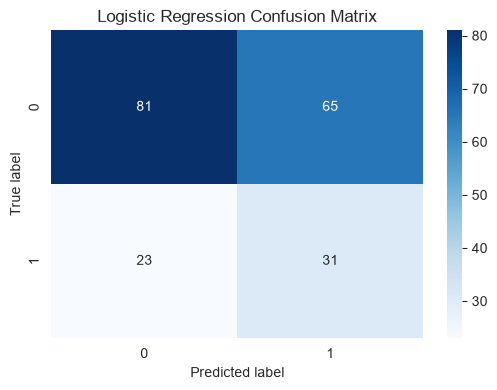

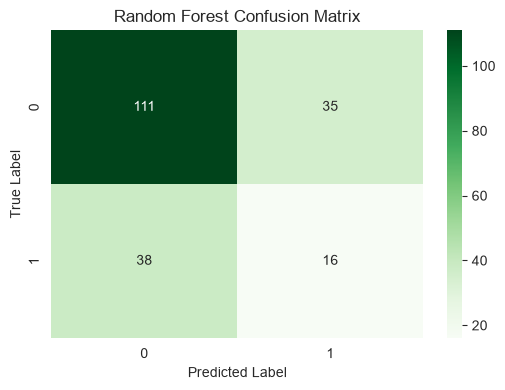

In [8]:
#Import evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#-------------------------------
#Predictions for each model
#-------------------------------


#Make predictions using logistic regression model
y_pred_logistic = logistic_model.predict(X_test)

#Predict using Random Forest Classifier
y_pred_rf = rf_class.predict(X_test)

#-------------------------------
#Accuracy scores
#-------------------------------
#Accuracy for Logistic Regression
acc_log = accuracy_score(y_test, y_pred_logistic)

#Accuracy for Random Forest Classifier
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Logistic Regression Accuracy: {acc_log:.3f}")
print(f"Random Forest Accuracy: {acc_rf:.3f}")

#-------------------------------
#Classification Reports
#-------------------------------
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logistic))

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

#-------------------------------
#Confusion Matrices
#-------------------------------
#Confusion matrix for Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_logistic)

#Confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

#-------------------------------
#Plot Confusion Matrix for  Logistic Regression
#-------------------------------
plt.figure(figsize=(6, 4))
sns.heatmap(cm_log, annot=True,fmt="d",cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

#-------------------------------
#Plot Confusion Matrix for Random Forest
#-------------------------------
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [9]:
#Import roc_auc evaluation metrics
from sklearn.metrics import roc_auc_score

#Predict probability for logistic regression
y_prob_log = logistic_model.predict_proba(X_test)[:, 1]

#ROC-AUC scores for logistic regression
auc_log = roc_auc_score(y_test, y_prob_log)

#Predict probability for random forest
y_prob_rf = rf_class.predict_proba(X_test)[:, 1]

#ROC-AUC scores for random forest
auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"Logistic Regression AUC Score: {auc_log:.3f}")
print(f"Random Forest AUC Score: {auc_rf:.3f}")

Logistic Regression AUC Score: 0.615
Random Forest AUC Score: 0.602


In [10]:
#Comparing this dataset 2 with moderately reduced features with my previous project dataset 1 which had all variables apart from customer ID and CREDIT_SCORE removed. The results show the reduced dataset resulted in lower overall accuracy for the Random Forest, but a good increase in recall and F1-score for default class. This suggests the reduced feature set produced a model that was better at identifying customers who defaulted, despite making fewer correct predictions overall.

R_CLOTHING_DEBT         0.031582
R_TAX_DEBT              0.029245
R_DEBT_INCOME           0.027643
R_EXPENDITURE_DEBT      0.025249
R_ENTERTAINMENT         0.023588
R_HEALTH                0.023086
R_GAMBLING              0.022519
R_EDUCATION             0.022340
R_GROCERIES             0.022015
R_DEBT_SAVINGS          0.021271
R_HEALTH_DEBT           0.021057
R_ENTERTAINMENT_DEBT    0.020995
R_GROCERIES_DEBT        0.020880
R_UTILITIES_DEBT        0.020600
R_CLOTHING_INCOME       0.020472
R_CLOTHING              0.020281
R_GROCERIES_INCOME      0.020058
T_ENTERTAINMENT_12      0.019676
R_FINES                 0.019575
R_TRAVEL_DEBT           0.019538


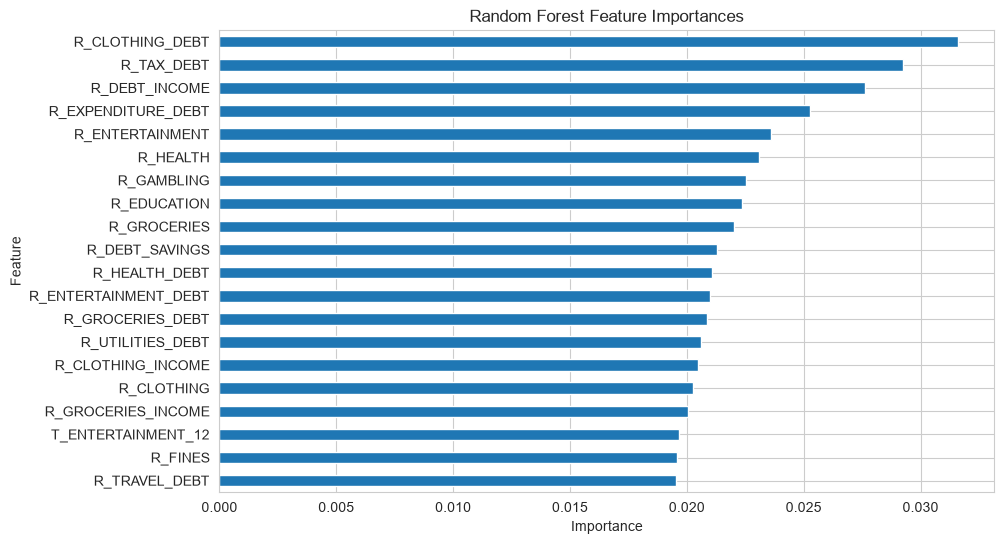

In [11]:
#Next used RF to say which variables were most to its predictions
feature_importances = pd.Series(
    rf_class.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

#Print top 20 feature importances
print(feature_importances.head(20).to_string())

#Plot the top 20
plt.figure(figsize=(10, 6))

feature_importances.head(20).sort_values().plot(kind='barh')

plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Further investigation to remove more variables for dataset 3

In [12]:

#Numerical variables
numerical_features = [
    #financial variables
    'INCOME',
    'SAVINGS',
    'DEBT',
    'R_SAVINGS_INCOME',
    'R_DEBT_INCOME',
    'R_DEBT_SAVINGS',

    # Clothing
    'T_CLOTHING_12',
    'R_CLOTHING',
    'R_CLOTHING_INCOME',
    'R_CLOTHING_SAVINGS',
    'R_CLOTHING_DEBT',

    # Education
    'T_EDUCATION_12',
    'R_EDUCATION',
    'R_EDUCATION_INCOME',
    'R_EDUCATION_SAVINGS',
    'R_EDUCATION_DEBT',

    # Entertainment
    'T_ENTERTAINMENT_12',
    'R_ENTERTAINMENT',
    'R_ENTERTAINMENT_INCOME',
    'R_ENTERTAINMENT_SAVINGS',
    'R_ENTERTAINMENT_DEBT',

    # Fines
    'T_FINES_12',
    'R_FINES',
    'R_FINES_INCOME',
    'R_FINES_SAVINGS',
    'R_FINES_DEBT',

    # Gambling
    'T_GAMBLING_12',
    'R_GAMBLING',
    'R_GAMBLING_INCOME',
    'R_GAMBLING_SAVINGS',
    'R_GAMBLING_DEBT',

    # Groceries
    'T_GROCERIES_12',
    'R_GROCERIES',
    'R_GROCERIES_INCOME',
    'R_GROCERIES_SAVINGS',
    'R_GROCERIES_DEBT',

    # Health
    'T_HEALTH_12',
    'R_HEALTH',
    'R_HEALTH_INCOME',
    'R_HEALTH_SAVINGS',
    'R_HEALTH_DEBT',

    # Housing
    'T_HOUSING_12',
    'R_HOUSING',
    'R_HOUSING_INCOME',
    'R_HOUSING_SAVINGS',
    'R_HOUSING_DEBT',

    # Tax
    'T_TAX_12',
    'R_TAX',
    'R_TAX_INCOME',
    'R_TAX_SAVINGS',
    'R_TAX_DEBT',

    # Travel
    'T_TRAVEL_12',
    'R_TRAVEL',
    'R_TRAVEL_INCOME',
    'R_TRAVEL_SAVINGS',
    'R_TRAVEL_DEBT',

    # Utilities
    'T_UTILITIES_12',
    'R_UTILITIES',
    'R_UTILITIES_INCOME',
    'R_UTILITIES_SAVINGS',
    'R_UTILITIES_DEBT',

    # Total expenditure
    'T_EXPENDITURE_12',
    'R_EXPENDITURE',
    'R_EXPENDITURE_INCOME',
    'R_EXPENDITURE_SAVINGS',
    'R_EXPENDITURE_DEBT',

]


In [14]:
print(len(numerical_features))

66


In [13]:
#Mann-Whitney U - Non-parametric test used to determine if there is a difference between two independent groups. When 2 variables are not normally distributed.
#Does the distribution of each numerical variable differ between customers who defaulted and those who didn't?
from scipy.stats import mannwhitneyu
import pandas as pd

#Store results
mann_whitney_results = []

#Test every numerical feature
for feature in numerical_features:

    #Separate the two groups
    group_0 = dataset2[dataset2['DEFAULT'] == 0][feature]
    group_1 = dataset2[dataset2['DEFAULT'] == 1][feature]

    #Perform Mann-Whitney U test
    statistic, p_value = mannwhitneyu(
        group_0,
        group_1,
        alternative='two-sided'
    )

    #Store results
    mann_whitney_results.append({
        'Feature':feature,
        'U_statistic':statistic,
        'p_value':p_value,
    })

# Convert results into a DataFrame
mw_results = pd.DataFrame(mann_whitney_results)

#Sort by p-value
mw_results = mw_results.sort_values('p_value')

#Display results
print(mw_results.to_string(index=False))

                Feature  U_statistic      p_value
          R_DEBT_INCOME      69311.5 3.899664e-15
             R_TAX_DEBT     133973.0 3.906586e-15
     R_EXPENDITURE_DEBT     132149.0 1.360678e-13
   R_ENTERTAINMENT_DEBT     129096.0 2.745979e-11
          R_HEALTH_DEBT     129088.5 2.796187e-11
        R_CLOTHING_DEBT     128769.0 4.683570e-11
       R_UTILITIES_DEBT     125974.0 3.620952e-09
         R_DEBT_SAVINGS      78960.0 3.486417e-08
       R_GROCERIES_DEBT     121841.0 9.728267e-07
                   DEBT      84870.5 4.508851e-05
          R_TRAVEL_DEBT     116442.5 3.115759e-04
    R_GROCERIES_SAVINGS      89133.0 2.331311e-03
 R_ENTERTAINMENT_INCOME     113569.5 3.868934e-03
    R_UTILITIES_SAVINGS      89957.0 4.447647e-03
     T_ENTERTAINMENT_12     113194.5 5.145579e-03
          R_TAX_SAVINGS     113019.5 5.711598e-03
     R_GROCERIES_INCOME      90575.5 7.056464e-03
       R_SAVINGS_INCOME     110918.0 2.477421e-02
  R_EXPENDITURE_SAVINGS      92565.0 2.701745e-02


In [15]:
#Select statistically significant features
significant_features = mw_results[mw_results['p_value'] < 0.05]

print("Number of statistically significant features:",
      len(significant_features))

print(significant_features.to_string(index=False))

Number of statistically significant features: 21
               Feature  U_statistic      p_value
         R_DEBT_INCOME      69311.5 3.899664e-15
            R_TAX_DEBT     133973.0 3.906586e-15
    R_EXPENDITURE_DEBT     132149.0 1.360678e-13
  R_ENTERTAINMENT_DEBT     129096.0 2.745979e-11
         R_HEALTH_DEBT     129088.5 2.796187e-11
       R_CLOTHING_DEBT     128769.0 4.683570e-11
      R_UTILITIES_DEBT     125974.0 3.620952e-09
        R_DEBT_SAVINGS      78960.0 3.486417e-08
      R_GROCERIES_DEBT     121841.0 9.728267e-07
                  DEBT      84870.5 4.508851e-05
         R_TRAVEL_DEBT     116442.5 3.115759e-04
   R_GROCERIES_SAVINGS      89133.0 2.331311e-03
R_ENTERTAINMENT_INCOME     113569.5 3.868934e-03
   R_UTILITIES_SAVINGS      89957.0 4.447647e-03
    T_ENTERTAINMENT_12     113194.5 5.145579e-03
         R_TAX_SAVINGS     113019.5 5.711598e-03
    R_GROCERIES_INCOME      90575.5 7.056464e-03
      R_SAVINGS_INCOME     110918.0 2.477421e-02
 R_EXPENDITURE_SAVIN

In [16]:
significant_features_names = significant_features['Feature'].to_list()
print(significant_features_names)

['R_DEBT_INCOME', 'R_TAX_DEBT', 'R_EXPENDITURE_DEBT', 'R_ENTERTAINMENT_DEBT', 'R_HEALTH_DEBT', 'R_CLOTHING_DEBT', 'R_UTILITIES_DEBT', 'R_DEBT_SAVINGS', 'R_GROCERIES_DEBT', 'DEBT', 'R_TRAVEL_DEBT', 'R_GROCERIES_SAVINGS', 'R_ENTERTAINMENT_INCOME', 'R_UTILITIES_SAVINGS', 'T_ENTERTAINMENT_12', 'R_TAX_SAVINGS', 'R_GROCERIES_INCOME', 'R_SAVINGS_INCOME', 'R_EXPENDITURE_SAVINGS', 'R_HOUSING_DEBT', 'R_GROCERIES']


In [17]:
#Adding Benjamini-Hochberg correction
from statsmodels.stats.multitest import multipletests

mw_results['adjusted_p_value'] = multipletests(
    mw_results['p_value'],
    method='fdr_bh'
) [1]

#Significant after correction
significant_features_corrected = mw_results[
    mw_results['adjusted_p_value'] < 0.05
].sort_values('adjusted_p_value')

print(
    significant_features_corrected.to_string(index=False)
)

               Feature  U_statistic      p_value  adjusted_p_value
         R_DEBT_INCOME      69311.5 3.899664e-15      1.289173e-13
            R_TAX_DEBT     133973.0 3.906586e-15      1.289173e-13
    R_EXPENDITURE_DEBT     132149.0 1.360678e-13      2.993491e-12
  R_ENTERTAINMENT_DEBT     129096.0 2.745979e-11      3.690967e-10
         R_HEALTH_DEBT     129088.5 2.796187e-11      3.690967e-10
       R_CLOTHING_DEBT     128769.0 4.683570e-11      5.151927e-10
      R_UTILITIES_DEBT     125974.0 3.620952e-09      3.414040e-08
        R_DEBT_SAVINGS      78960.0 3.486417e-08      2.876294e-07
      R_GROCERIES_DEBT     121841.0 9.728267e-07      7.134063e-06
                  DEBT      84870.5 4.508851e-05      2.975842e-04
         R_TRAVEL_DEBT     116442.5 3.115759e-04      1.869455e-03
   R_GROCERIES_SAVINGS      89133.0 2.331311e-03      1.282221e-02
R_ENTERTAINMENT_INCOME     113569.5 3.868934e-03      1.964228e-02
   R_UTILITIES_SAVINGS      89957.0 4.447647e-03      2.096748

In [27]:
#LASSO: When I consider all these predictors together, which ones actually contribute to predicting DEFAULT
#Create LASSO logistic regression model
lasso_model = Pipeline([
    ('scaler',StandardScaler()),
    ('model', LogisticRegression(
        l1_ratio=1,
        solver='liblinear',
        C=1.0,
        class_weight='balanced',
        random_state=42,
        max_iter=5000,
    ))
])

#Fit LASSO model
lasso_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](68,)","['INCOME','SAVINGS','DEBT',...,'R_EXPENDITURE_DEBT','CAT_CREDIT_CARD', 'CAT_DEPENDENTS']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,68
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [28]:
#fit model
lasso_model.fit(X_train, y_train)

#Extract LASSO coefficients
lasso_coefficients = pd.Series(
    lasso_model.named_steps['model'].coef_[0],
    index=X_train.columns
)

#Sort by coefficient
lasso_coefficients = lasso_coefficients.sort_values()

print(lasso_coefficients.to_string())

R_TAX_DEBT                -0.754425
R_FINES_INCOME            -0.441685
T_GROCERIES_12            -0.387311
R_DEBT_SAVINGS            -0.319314
T_EDUCATION_12            -0.313420
R_TRAVEL_DEBT             -0.236808
R_EXPENDITURE_DEBT        -0.228801
R_HEALTH_INCOME           -0.211786
R_GAMBLING_INCOME         -0.184131
T_HOUSING_12              -0.175178
T_TRAVEL_12               -0.170382
DEBT                      -0.154834
R_CLOTHING                -0.153354
R_TAX_INCOME              -0.134173
R_HOUSING_SAVINGS         -0.133292
R_ENTERTAINMENT_DEBT      -0.122209
R_UTILITIES_INCOME        -0.118753
R_TRAVEL_SAVINGS          -0.108653
R_FINES_DEBT              -0.086527
R_HOUSING                 -0.082406
R_TAX                     -0.039997
R_UTILITIES               -0.033747
R_GROCERIES               -0.033726
R_GROCERIES_DEBT          -0.022145
R_EDUCATION               -0.010030
R_HOUSING_DEBT            -0.006397
R_TRAVEL                  -0.001311
R_HEALTH_DEBT              0

In [29]:
#Get only the variables LASSO retained
#Select variables with non-zero LASSO coefficients
lasso_selected = lasso_coefficients[
    lasso_coefficients !=0
]

print("Number of features selected by LASSO:", len(lasso_selected))
print(lasso_selected.to_string())

Number of features selected by LASSO: 54
R_TAX_DEBT             -0.754425
R_FINES_INCOME         -0.441685
T_GROCERIES_12         -0.387311
R_DEBT_SAVINGS         -0.319314
T_EDUCATION_12         -0.313420
R_TRAVEL_DEBT          -0.236808
R_EXPENDITURE_DEBT     -0.228801
R_HEALTH_INCOME        -0.211786
R_GAMBLING_INCOME      -0.184131
T_HOUSING_12           -0.175178
T_TRAVEL_12            -0.170382
DEBT                   -0.154834
R_CLOTHING             -0.153354
R_TAX_INCOME           -0.134173
R_HOUSING_SAVINGS      -0.133292
R_ENTERTAINMENT_DEBT   -0.122209
R_UTILITIES_INCOME     -0.118753
R_TRAVEL_SAVINGS       -0.108653
R_FINES_DEBT           -0.086527
R_HOUSING              -0.082406
R_TAX                  -0.039997
R_UTILITIES            -0.033747
R_GROCERIES            -0.033726
R_GROCERIES_DEBT       -0.022145
R_EDUCATION            -0.010030
R_HOUSING_DEBT         -0.006397
R_TRAVEL               -0.001311
R_CLOTHING_SAVINGS      0.000021
R_FINES                 0.006946
R_

In [30]:
#Output of Lasso is 54 so seeing what happens with strong regularlisation
C_values = [1.0, 0.5, 0.1, 0.05, 0.01]

for C in C_values:
    lasso_model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            l1_ratio=1,
            solver = 'saga',
            C=C,
            class_weight='balanced',
            random_state=42,
            max_iter=5000,
        ))
    ])

    lasso_model.fit(X_train, y_train)

    coefficients = lasso_model.named_steps['model'].coef_[0]

    selected = coefficients[coefficients !=0]

    print(f"C = {C}: {len(selected)} features selected")

C = 1.0: 55 features selected
C = 0.5: 48 features selected
C = 0.1: 21 features selected
C = 0.05: 10 features selected
C = 0.01: 1 features selected


In [31]:
#See which 10 features the C=0.05 Lasso had
#Fit LASSO with C = 0.05
lasso_10 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        C=0.05,
        solver='saga',
        l1_ratio=1,
        class_weight='balanced',
        random_state=42,
        max_iter=5000
    ))
])

lasso_10.fit(X_train, y_train)

#Get coefficients
lasso_coefficients_10 = pd.Series(
    lasso_10.named_steps['model'].coef_[0],
    index=X_train.columns
)

#Select non-zero coefficients
lasso_selected_10 = lasso_coefficients_10[
    lasso_coefficients_10 !=0
].sort_values()

print("Number of features selected:",
      len(lasso_selected_10))

print(lasso_selected_10.to_string())

Number of features selected: 10
R_TAX_DEBT            -0.141123
T_EDUCATION_12        -0.039033
R_EXPENDITURE_DEBT    -0.034379
R_FINES_INCOME        -0.016306
R_HEALTH               0.001033
R_GROCERIES_INCOME     0.017874
R_ENTERTAINMENT        0.040138
CAT_CREDIT_CARD        0.044671
R_GROCERIES_SAVINGS    0.053332
R_DEBT_INCOME          0.463175


In [32]:
#Let's see C=0.1 which is LASSO with weaker regularisation
lasso_21 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        C=0.1,
        solver='saga',
        l1_ratio=1,
        class_weight='balanced',
        random_state=42,
        max_iter=5000
    ))
])

#Fit LASSO
lasso_21.fit(X_train, y_train)

#Get coefficients
lasso_coefficients_21 = pd.Series(
    lasso_21.named_steps['model'].coef_[0],
    index=X_train.columns
)

#Select non-zero coeffcients
lasso_selected_21 = lasso_coefficients_21[
    lasso_coefficients_21 !=0
].sort_values()

print("Number of features selected:",
      len(lasso_selected_21))

print(lasso_selected_21.to_string())

Number of features selected: 21
R_TAX_DEBT                -0.317289
T_EDUCATION_12            -0.165643
R_FINES_INCOME            -0.103275
R_HOUSING_SAVINGS         -0.068733
R_HEALTH_INCOME           -0.051255
R_EXPENDITURE_DEBT        -0.050392
R_TRAVEL_DEBT             -0.049812
T_HOUSING_12              -0.045760
R_CLOTHING                -0.017156
R_HEALTH_DEBT             -0.000118
R_ENTERTAINMENT_SAVINGS    0.004676
R_EDUCATION_SAVINGS        0.010208
R_EXPENDITURE_INCOME       0.021781
T_FINES_12                 0.027868
R_HEALTH                   0.047784
R_SAVINGS_INCOME           0.080101
R_ENTERTAINMENT            0.085436
CAT_DEPENDENTS             0.098494
CAT_CREDIT_CARD            0.111015
R_GROCERIES_SAVINGS        0.119169
R_DEBT_INCOME              0.482338


In [33]:
#Next using the mann-whitney and Benjamini Hochberg, LASSO=0.1, Random Forest top 20 combine together in one table to see which variables have the strongest evidence across the methods
#Create the three lists

#Mann-Whitney significant features after BH correction
mw_features = significant_features_corrected['Feature'].tolist()

#LASSO features at C=0.1
lasso_features = lasso_selected_21.index.tolist()

#Top 20 Random Forest features
rf_features = feature_importances.head(20).index.tolist()

In [36]:
#Next create a consensus score
#Combine all features from the three methods
all_features = set(mw_features) | set(lasso_features) | set(rf_features)

#Create a dataframe
feature_selection = pd.DataFrame(
    index=sorted(all_features)
)

#Score each feature
feature_selection['Mann_Whitney'] = (
    feature_selection.index.isin(mw_features).astype(int)
)

feature_selection['LASSO'] = (
    feature_selection.index.isin(lasso_features).astype(int)
)

feature_selection['Random_Forest'] = (
    feature_selection.index.isin(rf_features).astype(int)
)

#Total consensus score
feature_selection['Consensus_Score'] = (
    feature_selection['Mann_Whitney']
    + feature_selection['LASSO']
    + feature_selection ['Random_Forest']
)

#Sort by strongest consensus
feature_selection = feature_selection.sort_values(
    'Consensus_Score',
    ascending=False
)

print(feature_selection.to_string())

                         Mann_Whitney  LASSO  Random_Forest  Consensus_Score
R_TAX_DEBT                          1      1              1                3
R_DEBT_INCOME                       1      1              1                3
R_EXPENDITURE_DEBT                  1      1              1                3
R_TRAVEL_DEBT                       1      1              1                3
R_HEALTH_DEBT                       1      1              1                3
R_UTILITIES_DEBT                    1      0              1                2
R_ENTERTAINMENT_DEBT                1      0              1                2
R_GROCERIES_SAVINGS                 1      1              0                2
R_GROCERIES_INCOME                  1      0              1                2
R_GROCERIES_DEBT                    1      0              1                2
R_HEALTH                            0      1              1                2
R_ENTERTAINMENT                     0      1              1                2

In [37]:
#Narrow down consensus
print(
    feature_selection[
        feature_selection['Consensus_Score'] >=2
    ].to_string()
)

                      Mann_Whitney  LASSO  Random_Forest  Consensus_Score
R_TAX_DEBT                       1      1              1                3
R_DEBT_INCOME                    1      1              1                3
R_EXPENDITURE_DEBT               1      1              1                3
R_TRAVEL_DEBT                    1      1              1                3
R_HEALTH_DEBT                    1      1              1                3
R_UTILITIES_DEBT                 1      0              1                2
R_ENTERTAINMENT_DEBT             1      0              1                2
R_GROCERIES_SAVINGS              1      1              0                2
R_GROCERIES_INCOME               1      0              1                2
R_GROCERIES_DEBT                 1      0              1                2
R_HEALTH                         0      1              1                2
R_ENTERTAINMENT                  0      1              1                2
R_DEBT_SAVINGS                   1    

                      R_TAX_DEBT  R_DEBT_INCOME  R_EXPENDITURE_DEBT  R_TRAVEL_DEBT  R_HEALTH_DEBT  R_UTILITIES_DEBT  R_ENTERTAINMENT_DEBT  R_GROCERIES_SAVINGS  R_GROCERIES_INCOME  R_GROCERIES_DEBT  R_HEALTH  R_ENTERTAINMENT  R_DEBT_SAVINGS  T_ENTERTAINMENT_12  R_CLOTHING_DEBT  R_CLOTHING
R_TAX_DEBT              1.000000      -0.279661            0.646014       0.475275       0.395913          0.621138              0.733837            -0.059919           -0.037010          0.614047 -0.061979         0.022114       -0.117954            0.043274         0.817401   -0.028766
R_DEBT_INCOME          -0.279661       1.000000           -0.353934      -0.266892      -0.304392         -0.341290             -0.320598             0.197445            0.218863         -0.322949 -0.023290         0.028703        0.532274           -0.044488        -0.271394   -0.026952
R_EXPENDITURE_DEBT      0.646014      -0.353934            1.000000       0.828111       0.829241          0.917110              0.83

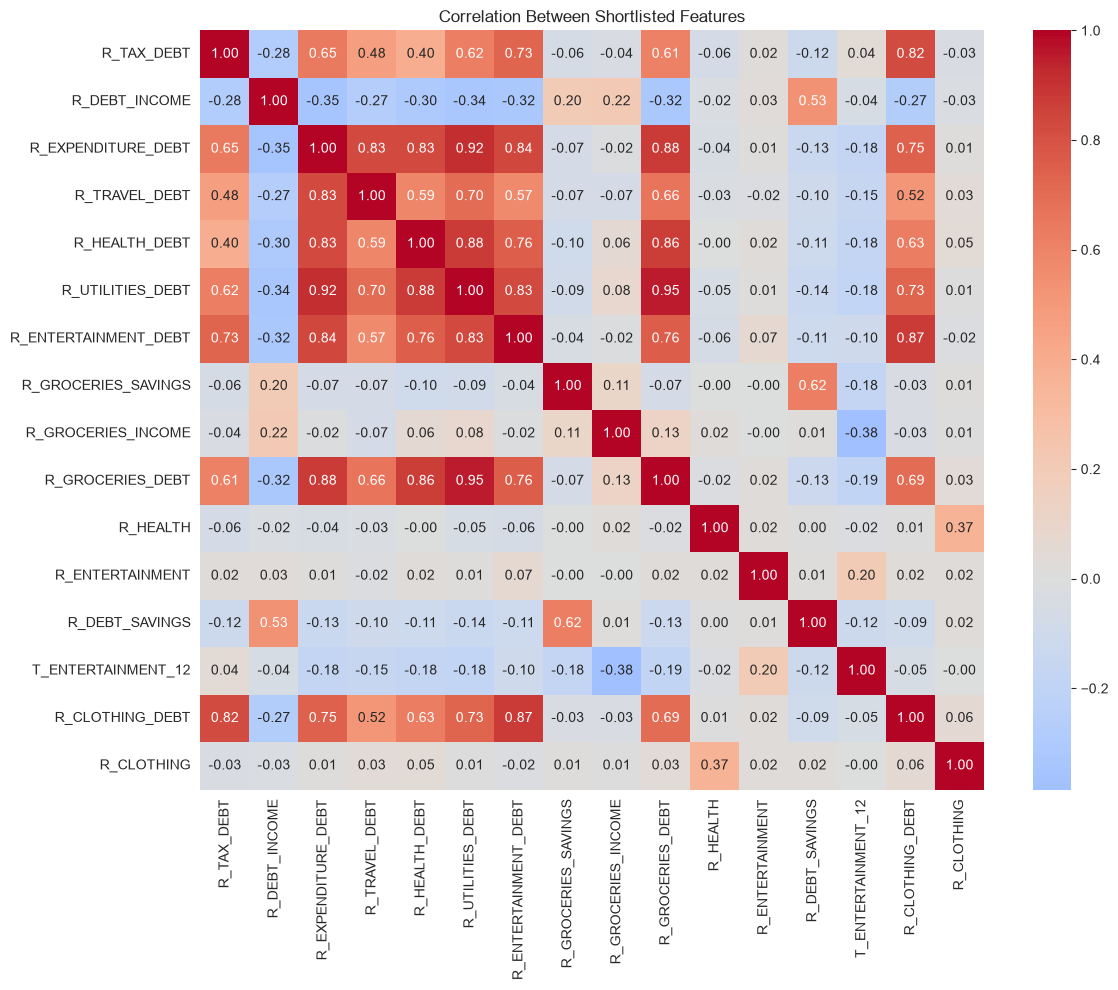

In [40]:
#Now correlation analysis of these variables
shortlisted_features = feature_selection [
    feature_selection['Consensus_Score'] >= 2
].index.tolist()

#Calculate correlations between shortlisted features
shortlist_corr = dataset2[shortlisted_features].corr()

#Display the correlation matrix
print(shortlist_corr.to_string())

#Visualise matrix as heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    shortlist_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Shortlisted Features")
plt.tight_layout()
plt.show()

In [41]:
#Find highly correlated pairs among the 16 shortlisted features
corr_pairs = shortlist_corr.unstack()

#Remove self-correlations
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) !=
                        corr_pairs.index.get_level_values(1)]

#Remove duplicate pairs
corr_pairs = corr_pairs[~corr_pairs.index.map(
    lambda x: tuple(sorted(x)) in []
)]

upper = shortlist_corr.where(
    np.triu(np.ones(shortlist_corr.shape), k=1).astype(bool)
)

high_corr_pairs = upper.stack().sort_values(
    key=abs,
    ascending=False
)

high_corr_pairs = high_corr_pairs[
    abs(high_corr_pairs)>0.8
]

print(high_corr_pairs.to_string())

R_UTILITIES_DEBT      R_GROCERIES_DEBT        0.953496
R_EXPENDITURE_DEBT    R_UTILITIES_DEBT        0.917110
                      R_GROCERIES_DEBT        0.879746
R_HEALTH_DEBT         R_UTILITIES_DEBT        0.879101
R_ENTERTAINMENT_DEBT  R_CLOTHING_DEBT         0.871527
R_HEALTH_DEBT         R_GROCERIES_DEBT        0.864991
R_EXPENDITURE_DEBT    R_ENTERTAINMENT_DEBT    0.838574
                      R_HEALTH_DEBT           0.829241
                      R_TRAVEL_DEBT           0.828111
R_UTILITIES_DEBT      R_ENTERTAINMENT_DEBT    0.827670
R_TAX_DEBT            R_CLOTHING_DEBT         0.817401


In [42]:
#So core model 5 features that got support from all 3 methods
#R_TAX_DEBT, R_DEBT_INCOME,R_EXPENDITURE_DEBT,R_TRAVEL_DEBT,R_HEALTH_DEBT
dataset3_features = [
    'R_TAX_DEBT',
    'R_DEBT_INCOME',
    'R_EXPENDITURE_DEBT',
    'R_TRAVEL_DEBT',
    'R_HEALTH_DEBT'
]

dataset3 = dataset2[
    dataset3_features + ['DEFAULT']
].copy()

print(dataset3.shape)
print(dataset3.columns.tolist())


(1000, 6)
['R_TAX_DEBT', 'R_DEBT_INCOME', 'R_EXPENDITURE_DEBT', 'R_TRAVEL_DEBT', 'R_HEALTH_DEBT', 'DEFAULT']


In [63]:
#Using these 5 features to train models to see if there would be an improvement, as there are way less variables, and way less multicollinearity

#Separate predictors and target
X = dataset3.drop(columns=['DEFAULT'])
y = dataset3['DEFAULT']

#Train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (800, 5)
Test set: (200, 5)


In [47]:
#Logisitic Regression for dataset 3
#Import libraries
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

#Make pipeline
logistic_model_3 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced',
    ))
])

#Train Logistic Regression
logistic_model_3.fit(X_train, y_train)

#Make predictions
y_pred_logistic_3 = logistic_model_3.predict(X_test)

In [50]:
#Random Forest for dataset 3
from sklearn.ensemble import RandomForestClassifier

rf_class_3 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

#Train Random Forest
rf_class_3.fit(X_train, y_train)

#Make predictions
y_pred_rf_3 = rf_class_3.predict(X_test)

In [51]:
#Evaluate dataset3 models
#Import libraries
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    classification_report,
)

#Logistic Regression
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_logistic_3))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_logistic_3))

#Random Forest
print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_3))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_rf_3))

#Classification reports
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logistic_3))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf_3))

=== Logistic Regression ===
Accuracy: 0.61
Balanced Accuracy: 0.6006624953993376

=== Random Forest ===
Accuracy: 0.665
Balanced Accuracy: 0.6021960495644706

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.62      0.70       143
           1       0.38      0.58      0.46        57

    accuracy                           0.61       200
   macro avg       0.58      0.60      0.58       200
weighted avg       0.67      0.61      0.63       200


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.75      0.76       143
           1       0.42      0.46      0.44        57

    accuracy                           0.67       200
   macro avg       0.60      0.60      0.60       200
weighted avg       0.67      0.67      0.67       200



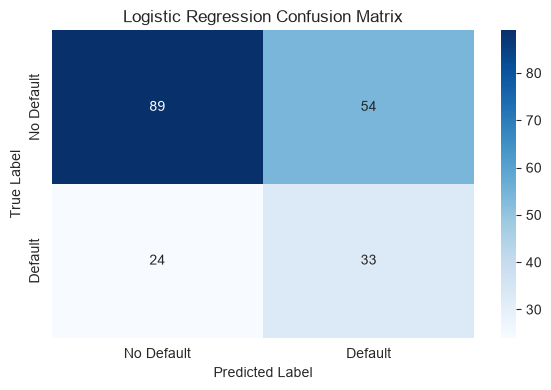

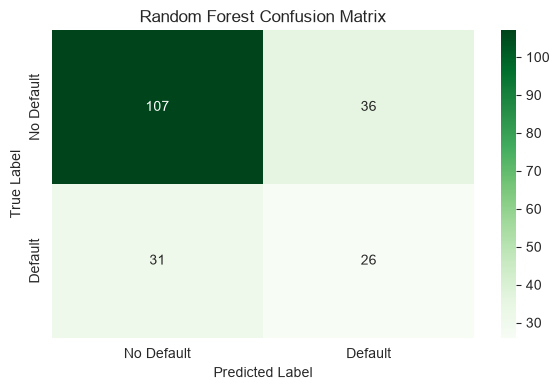

In [53]:
from fontTools.merge import cmap
#Visualise it as a heatmap
#Import libraries
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

#-----------------------------
# Calculate confusion matrices
#-------------------------------
cm_logistic_3 = confusion_matrix(y_test, y_pred_logistic_3)
cm_rf_3 = confusion_matrix(y_test, y_pred_rf_3)

#------------------------------
# Plot Logistic Regression
#------------------------------
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_logistic_3,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"],
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

#------------------------------
#Plot Random Forest
#------------------------------
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_rf_3,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"],
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [52]:
#Calculate ROC-AUC
#Predicted probabilities
y_prob_log_3 = logistic_model_3.predict_proba(X_test)[:, 1]
y_prob_rf_3 = rf_class_3.predict_proba(X_test)[:, 1]

#ROC-AUC
auc_log_3 = roc_auc_score(y_test, y_prob_log_3)
auc_rf_3 = roc_auc_score(y_test, y_prob_rf_3)

print("Logistic Regression ROC-AUC:", round(auc_log_3,3))
print("Random Forest ROC-AUC:", round(auc_rf_3,3))

Logistic Regression ROC-AUC: 0.66
Random Forest ROC-AUC: 0.623


In [54]:
#database 4 this will have the five core variables and selected further variables using previous EDA. To see whether dataset 3 with the core 5 variables will perform better or if dataset 4 with additional info will perform better
dataset4_features = [
    #Five core variables
    'R_TAX_DEBT',
    'R_DEBT_INCOME',
    'R_EXPENDITURE_DEBT',
    'R_TRAVEL_DEBT',
    'R_HEALTH_DEBT',

    #Additional variables
    'R_GROCERIES_SAVINGS',
    'R_GROCERIES_INCOME',
    'R_HEALTH',
    'R_ENTERTAINMENT'
]

dataset4 = dataset2[
    dataset4_features + ['DEFAULT']
].copy()

print("Dataset 4 shape:", dataset4.shape)
print(dataset4_features)

Dataset 4 shape: (1000, 10)
['R_TAX_DEBT', 'R_DEBT_INCOME', 'R_EXPENDITURE_DEBT', 'R_TRAVEL_DEBT', 'R_HEALTH_DEBT', 'R_GROCERIES_SAVINGS', 'R_GROCERIES_INCOME', 'R_HEALTH', 'R_ENTERTAINMENT']


In [69]:
#Using these 9 features to train models to see if there would be an improvement

#Seperate predictors and target
X= dataset4.drop(columns=['DEFAULT'])
y = dataset4['DEFAULT']

#Train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (800, 9)
Test set: (200, 9)


In [70]:
#Logistic Regression for dataset 4
#Import libraries
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

#Make pipeline
logistic_model_4 = Pipeline ([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ))
])

#Train Logistic Regression
logistic_model_4.fit(X_train, y_train)

#Make predictions
y_pred_logistic_4 = logistic_model_4.predict(X_test)

In [71]:
#Random Forest for dataset 4
from sklearn.ensemble import RandomForestClassifier

rf_class_4 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

#Train Random Forest
rf_class_4.fit(X_train, y_train)

#Make predictions
y_pred_rf_4 = rf_class_4.predict(X_test)

In [72]:
#Evaluate dataset4 models
#Import libraries
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    classification_report,
)

#Logistic Regression
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_logistic_4))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_logistic_4))

#Random Forest
print("\n ===Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_4))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_rf_4))

#Classification reports
print("\n Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logistic_4))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf_4))

=== Logistic Regression ===
Accuracy: 0.63
Balanced Accuracy: 0.6251993620414673

 ===Random Forest ===
Accuracy: 0.675
Balanced Accuracy: 0.5775364985891301

 Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.64      0.71       143
           1       0.40      0.61      0.49        57

    accuracy                           0.63       200
   macro avg       0.60      0.63      0.60       200
weighted avg       0.69      0.63      0.65       200


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.80      0.78       143
           1       0.42      0.35      0.38        57

    accuracy                           0.68       200
   macro avg       0.59      0.58      0.58       200
weighted avg       0.66      0.68      0.67       200



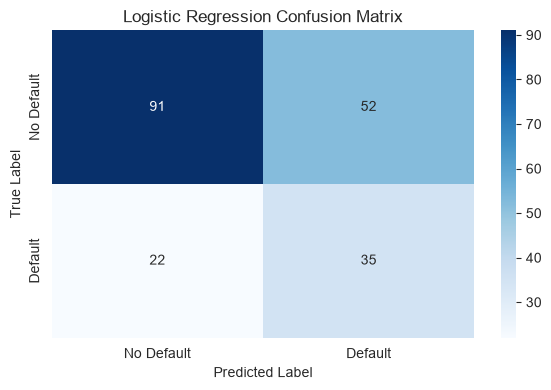

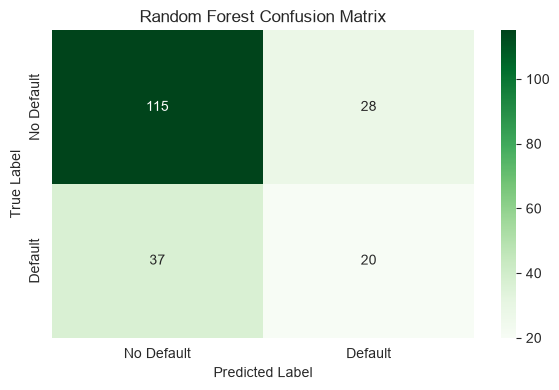

In [73]:
from fontTools.merge import cmap
#Visualise it as a heatmap
#Import libraries
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

#-----------------------------
# Calculate confusion matrices
#-------------------------------
cm_logistic_4 = confusion_matrix(y_test, y_pred_logistic_4)
cm_rf_4 = confusion_matrix(y_test, y_pred_rf_4)

#------------------------------
# Plot Logistic Regression
#------------------------------
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_logistic_4,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"],)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

#------------------------------
#Plot Random Forest
#------------------------------
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_rf_4,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"],
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [60]:
#Calculate ROC-AUC
#Predicted probabilities
y_prob_log_4 = logistic_model_4.predict_proba(X_test)[:, 1]
y_prob_rf_4 = rf_class_4.predict_proba(X_test)[:, 1]

#ROC-AUC
auc_log_4 = roc_auc_score(y_test, y_prob_log_4)
auc_rf_4 = roc_auc_score(y_test, y_prob_rf_4)

print("Logistic Regression ROC-AUC:", round(auc_log_4,3))
print("Random Forest ROC-AUC:", round(auc_rf_4,3))

Logistic Regression ROC-AUC: 0.682
Random Forest ROC-AUC: 0.607


In [74]:
#Run 5-fold cross validation
from sklearn.model_selection import StratifiedKFold, cross_val_score

#5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#Logistic Regression
logistic_cv_scores = cross_val_score(
    logistic_model_4,
    X,
    y,
    cv=cv,
    scoring='roc_auc',
)

#Random Forest
rf_cv_scores = cross_val_score(
    rf_class_4,
    X,
    y,
    cv=cv,
    scoring='roc_auc'
)

#Results
print("Logistic Regression ROC-AUC scores:")
print(logistic_cv_scores)

print("\nLogistic Regression mean ROC-AUC:",
        round(logistic_cv_scores.mean(),3))

print("Logistic Regression SD:",
      round(logistic_cv_scores.std(),3))

print("\nRandom Forest ROC-AUC scores:")
print(rf_cv_scores)

print("\nRandom Forest mean ROC-AUC:",
      round(rf_cv_scores.mean(), 3))

print("Random Forest SD:",
      round(rf_cv_scores.std(), 3))

Logistic Regression ROC-AUC scores:
[0.68850448 0.67930315 0.68016194 0.60728745 0.70510913]

Logistic Regression mean ROC-AUC: 0.672
Logistic Regression SD: 0.034

Random Forest ROC-AUC scores:
[0.5661882  0.66010305 0.60556987 0.55214084 0.63411458]

Random Forest mean ROC-AUC: 0.604
Random Forest SD: 0.04


In [61]:
#Run 5-fold cross validation for
from sklearn.model_selection import StratifiedKFold, cross_val_score

#5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#Logistic Regression
logistic_cv_scores = cross_val_score(
    logistic_model_3,
    X,
    y,
    cv=cv,
    scoring='roc_auc',
)

#Random Forest
rf_cv_scores = cross_val_score(
    rf_class_3,
    X,
    y,
    cv=cv,
    scoring='roc_auc'
)

#Results
print("Logistic Regression ROC-AUC scores:")
print(logistic_cv_scores)

print("\nLogistic Regression mean ROC-AUC:",
        round(logistic_cv_scores.mean(),3))

print("Logistic Regression SD:",
      round(logistic_cv_scores.std(),3))

print("\nRandom Forest ROC-AUC scores:")
print(rf_cv_scores)

print("\nRandom Forest mean ROC-AUC:",
      round(rf_cv_scores.mean(), 3))

print("Random Forest SD:",
      round(rf_cv_scores.std(), 3))

Logistic Regression ROC-AUC scores:
[0.68850448 0.67930315 0.68016194 0.60728745 0.70510913]

Logistic Regression mean ROC-AUC: 0.672
Logistic Regression SD: 0.034

Random Forest ROC-AUC scores:
[0.5661882  0.66010305 0.60556987 0.55214084 0.63411458]

Random Forest mean ROC-AUC: 0.604
Random Forest SD: 0.04


In [64]:
#Run 5-fold cross validation for dataset 3
X_3 = dataset3.drop(columns=['DEFAULT'])
y_3 = dataset3['DEFAULT']

#Import libraries
from sklearn.model_selection import StratifiedKFold, cross_val_score

#5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#Logistic Regression
logistic_cv_scores_3 = cross_val_score(
    logistic_model_3,
    X_3,
    y_3,
    cv=cv,
    scoring='roc_auc',
)

#Random Forest
rf_cv_scores_3 = cross_val_score(
    rf_class_3,
    X_3,
    y_3,
    cv=cv,
    scoring='roc_auc'
)

#Results
print("Logistic Regression ROC-AUC scores:")
print(logistic_cv_scores_3)

print("\nLogistic Regression mean ROC-AUC:",
        round(logistic_cv_scores_3.mean(),3))

print("Logistic Regression SD:",
      round(logistic_cv_scores_3.std(),3))

print("\nRandom Forest ROC-AUC scores:")
print(rf_cv_scores_3)

print("\nRandom Forest mean ROC-AUC:",
      round(rf_cv_scores_3.mean(), 3))

print("Random Forest SD:",
      round(rf_cv_scores_3.std(), 3))

Logistic Regression ROC-AUC scores:
[0.65967366 0.70003681 0.67832168 0.61955588 0.67844742]

Logistic Regression mean ROC-AUC: 0.667
Logistic Regression SD: 0.027

Random Forest ROC-AUC scores:
[0.56324377 0.64550362 0.63949209 0.54336891 0.60534474]

Random Forest mean ROC-AUC: 0.599
Random Forest SD: 0.041


In [65]:
#Run 5-fold cross validation for dataset 4
X_4 = dataset4.drop(columns=['DEFAULT'])
y_4 = dataset4['DEFAULT']

#Import libraries
from sklearn.model_selection import StratifiedKFold, cross_val_score

#5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#Logistic Regression
logistic_cv_scores_4 = cross_val_score(
    logistic_model_4,
    X_4,
    y_4,
    cv=cv,
    scoring='roc_auc',
)

#Random Forest
rf_cv_scores_4 = cross_val_score(
    rf_class_4,
    X_4,
    y_4,
    cv=cv,
    scoring='roc_auc'
)

#Results
print("Logistic Regression ROC-AUC scores:")
print(logistic_cv_scores_4)

print("\nLogistic Regression mean ROC-AUC:",
        round(logistic_cv_scores_4.mean(),3))

print("Logistic Regression SD:",
      round(logistic_cv_scores_4.std(),3))

print("\nRandom Forest ROC-AUC scores:")
print(rf_cv_scores_4)

print("\nRandom Forest mean ROC-AUC:",
      round(rf_cv_scores_4.mean(), 3))

print("Random Forest SD:",
      round(rf_cv_scores_4.std(), 3))

Logistic Regression ROC-AUC scores:
[0.68850448 0.67930315 0.68016194 0.60728745 0.70510913]

Logistic Regression mean ROC-AUC: 0.672
Logistic Regression SD: 0.034

Random Forest ROC-AUC scores:
[0.5661882  0.66010305 0.60556987 0.55214084 0.63411458]

Random Forest mean ROC-AUC: 0.604
Random Forest SD: 0.04


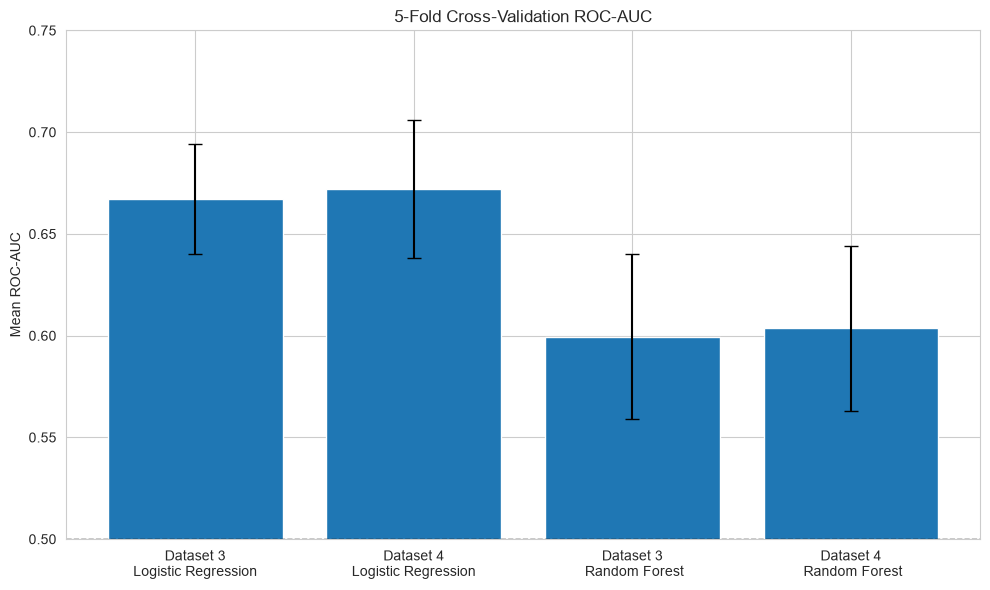

In [66]:
#Visualise CV results
import matplotlib.pyplot as plt
import numpy as np

models = [
    'Dataset 3\nLogistic Regression',
    'Dataset 4\nLogistic Regression',
    'Dataset 3\n Random Forest',
    'Dataset 4\n Random Forest',
]

means = [
    logistic_cv_scores_3.mean(),
    logistic_cv_scores_4.mean(),
    rf_cv_scores_3.mean(),
    rf_cv_scores_4.mean()
]

sd = [
    logistic_cv_scores_3.std(),
    logistic_cv_scores_4.std(),
    rf_cv_scores_3.std(),
    rf_cv_scores_4.std()
]

x = np.arange(len(models))

plt.figure(figsize=(10, 6))

plt.bar(
    x,
    means,
    yerr=sd,
    capsize=5,
)

plt.xticks(x,models)
plt.ylabel('Mean ROC-AUC')
plt.title('5-Fold Cross-Validation ROC-AUC')
plt.ylim(0.5,0.75)

plt.axhline(0.5, color='k', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

In [75]:
#Look at the coefficients
#Get Logistic Regression coefficients
coefficients = pd.Series(
    logistic_model_4.named_steps['model'].coef_[0],
    index=X_train.columns
)

#Sort by coefficent
coefficients = coefficients.sort_values()

print(coefficients)

R_TAX_DEBT            -0.450338
R_TRAVEL_DEBT         -0.177926
R_HEALTH_DEBT         -0.112794
R_EXPENDITURE_DEBT    -0.040907
R_ENTERTAINMENT        0.030836
R_GROCERIES_SAVINGS    0.052230
R_GROCERIES_INCOME     0.059565
R_HEALTH               0.108414
R_DEBT_INCOME          0.458909
dtype: float64


In [76]:
#Calculate odds ratio
import numpy as np

#Calculate odds ratio
odds_ratios = np.exp(coefficients)

#Put coefficients and odds ratios together
coefficient_table = pd.DataFrame({
    'Coefficient':coefficients,
    'Odds_Ratio': odds_ratios
})

print(coefficient_table)

                     Coefficient  Odds_Ratio
R_TAX_DEBT             -0.450338    0.637413
R_TRAVEL_DEBT          -0.177926    0.837005
R_HEALTH_DEBT          -0.112794    0.893335
R_EXPENDITURE_DEBT     -0.040907    0.959919
R_ENTERTAINMENT         0.030836    1.031316
R_GROCERIES_SAVINGS     0.052230    1.053618
R_GROCERIES_INCOME      0.059565    1.061375
R_HEALTH                0.108414    1.114509
R_DEBT_INCOME           0.458909    1.582347


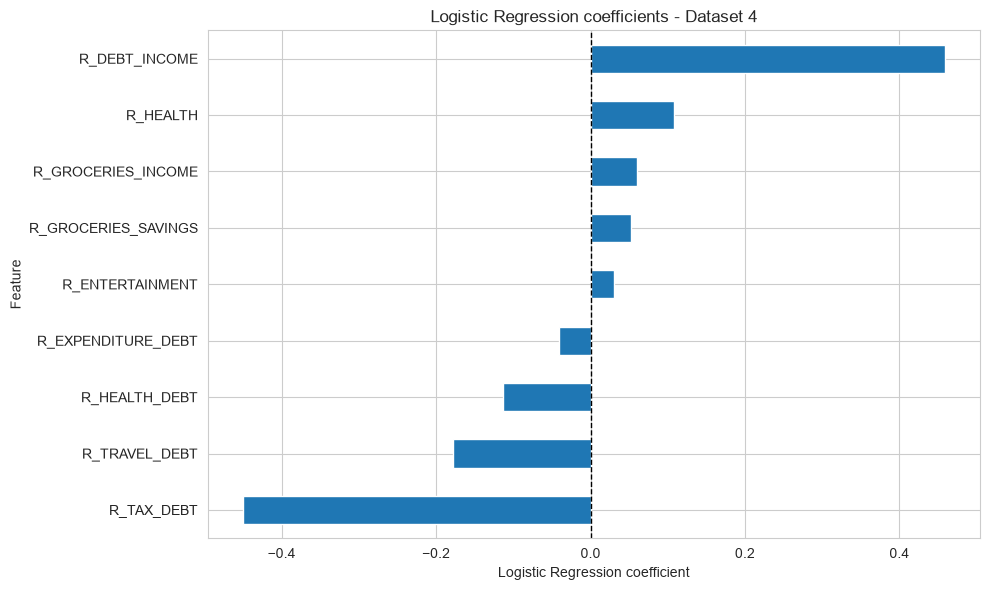

In [77]:
#Get Logistic Regression coefficients
coefficient = pd.Series(
    logistic_model_4.named_steps['model'].coef_[0],
    index=X_train.columns
)

#Sort coefficients
coefficients = coefficients.sort_values()

#Plot coefficients
plt.figure(figsize=(10, 6))

coefficients.plot(kind='barh')

plt.axvline(0, linestyle='--', color='k', linewidth=1)

plt.xlabel('Logistic Regression coefficient')
plt.ylabel("Feature")
plt.title("Logistic Regression coefficients - Dataset 4")

plt.tight_layout()
plt.show()